# 02: Training Baseline Model

This notebook trains a baseline MLP model using Morgan fingerprints for toxicity prediction.

## Objectives

1. Load and featurize data using fingerprints
2. Train baseline MLP model
3. Evaluate model performance
4. Save model and results



In [1]:
# Setup
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from src.data import load_clintox
from src.featurization import featurize_batch
from src.models import create_baseline_model
from src.train import train_baseline_model, evaluate_model
from src.utils import set_seed, get_default_config

# Set seed
set_seed(42)
config = get_default_config()

print("✓ Imports successful")



✓ Imports successful


## Load and Featurize Data

Load the ClinTox dataset and convert SMILES to fingerprint features.



In [2]:
# Load dataset
cache_dir = project_root / "data"
train_df, val_df, test_df = load_clintox(cache_dir=str(cache_dir), split_type="scaffold", seed=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Featurize SMILES to fingerprints
print("\nFeaturizing molecules...")
train_fps = featurize_batch(
    train_df['smiles'].tolist(),
    mode="fingerprint",
    radius=config['featurization']['fingerprint']['radius'],
    n_bits=config['featurization']['fingerprint']['n_bits']
)
val_fps = featurize_batch(
    val_df['smiles'].tolist(),
    mode="fingerprint",
    radius=config['featurization']['fingerprint']['radius'],
    n_bits=config['featurization']['fingerprint']['n_bits']
)
test_fps = featurize_batch(
    test_df['smiles'].tolist(),
    mode="fingerprint",
    radius=config['featurization']['fingerprint']['radius'],
    n_bits=config['featurization']['fingerprint']['n_bits']
)

print(f"✓ Fingerprints generated: {train_fps.shape[1]} bits")

# Prepare labels
train_labels = train_df['CT_TOX'].values.reshape(-1, 1)
val_labels = val_df['CT_TOX'].values.reshape(-1, 1)
test_labels = test_df['CT_TOX'].values.reshape(-1, 1)



No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'
'split' is deprecated.  Use 'splitter' instead.


Train: 1184, Val: 148, Test: 148

Featurizing molecules...
✓ Fingerprints generated: 2048 bits


## Create DataLoaders

Convert data to PyTorch tensors and create DataLoaders for training.



In [3]:
# Convert to tensors
train_dataset = TensorDataset(
    torch.FloatTensor(train_fps),
    torch.FloatTensor(train_labels)
)
val_dataset = TensorDataset(
    torch.FloatTensor(val_fps),
    torch.FloatTensor(val_labels)
)
test_dataset = TensorDataset(
    torch.FloatTensor(test_fps),
    torch.FloatTensor(test_labels)
)

# Create DataLoaders
batch_size = config['training']['batch_size']
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"✓ DataLoaders created (batch_size={batch_size})")



✓ DataLoaders created (batch_size=128)


## Create and Train Baseline Model

Initialize the MLP model and train it on fingerprint features.



In [4]:
# Create model
model = create_baseline_model(
    input_dim=config['featurization']['fingerprint']['n_bits'],
    hidden_dims=config['baseline_model']['hidden_dims'],
    num_tasks=1,
    dropout=config['baseline_model']['dropout']
)

print("Model architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")



Model architecture:
FingerprintMLP(
  (features): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
  )
  (output): Linear(in_features=128, out_features=1, bias=True)
)

Total parameters: 1,213,441
Trainable parameters: 1,213,441


In [5]:
# Train model
device = config['training']['device']
history = train_baseline_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=config['training']['num_epochs'],
    learning_rate=config['training']['learning_rate'],
    device=device,
    verbose=True
)



Epoch 10/50 - Train Loss: 0.0748, Val Loss: 0.8139, Val AUC: 0.6322
Epoch 20/50 - Train Loss: 0.0348, Val Loss: 0.8529, Val AUC: 0.6444
Epoch 30/50 - Train Loss: 0.0337, Val Loss: 0.9267, Val AUC: 0.6484
Epoch 40/50 - Train Loss: 0.0293, Val Loss: 1.1513, Val AUC: 0.6494
Epoch 50/50 - Train Loss: 0.0264, Val Loss: 1.2951, Val AUC: 0.6413


## Visualize Training Progress

Plot training and validation loss curves.



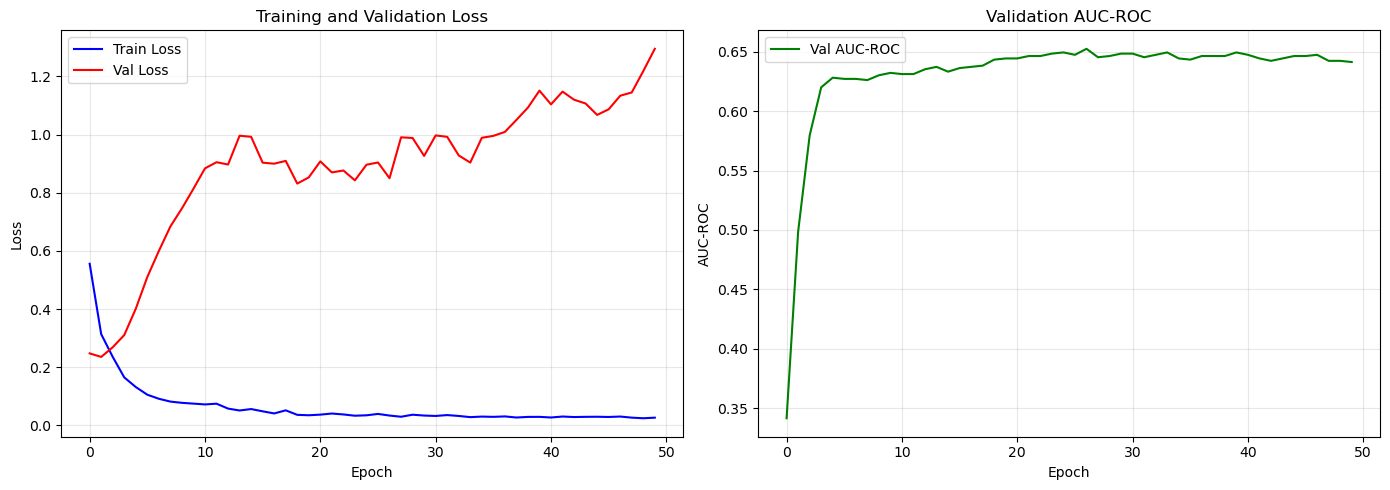

Best validation AUC: 0.6525


In [6]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'], label='Val Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation AUC curve
axes[1].plot(history['val_auc'], label='Val AUC-ROC', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('Validation AUC-ROC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best validation AUC: {max(history['val_auc']):.4f}")



## Evaluate on Test Set

Evaluate the trained model on the held-out test set.



In [7]:
# Evaluate on test set
test_metrics = evaluate_model(model, test_loader, device=device)

print("Test Set Performance:")
print("=" * 50)
for metric, value in test_metrics.items():
    print(f"{metric.upper()}: {value:.4f}")



Test Set Performance:
AUC_ROC: 0.7167
ACCURACY: 0.9392
F1: 0.4706
PR_AUC: 0.4497


## Save Model and Results

Save the trained model and evaluation metrics for future use.



In [8]:
# Save model
models_dir = project_root / "models"
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "baseline_mlp_model.pt"
torch.save(model.state_dict(), model_path)
print(f"✓ Model saved to: {model_path}")

# Save metrics
from src.utils import save_metrics
metrics_path = models_dir / "baseline_metrics.txt"
save_metrics(test_metrics, metrics_path)
print(f"✓ Metrics saved to: {metrics_path}")



✓ Model saved to: /Users/nguyennghia/PROJECT/Torch_molecule/models/baseline_mlp_model.pt
✓ Metrics saved to: /Users/nguyennghia/PROJECT/Torch_molecule/models/baseline_metrics.txt


## Summary

✓ Baseline MLP model trained on fingerprint features  
✓ Model evaluated on test set  
✓ Results saved  

**Next Steps:**
- Proceed to `03_training_gnn.ipynb` to train torch-molecule GNN model and compare performance

